In [30]:
import stim
import numpy as np

from spiderwarp.csscode import CSSCode
from spiderwarp.utils import load_state_prep_circuit
from spiderwarp.stim_utils import steane_se_from_stim_state_prep, get_num_measurements, perfect_state_from_code
from spiderwarp.path_cover import CoveredZXGraph
from spiderwarp.path_cover_metrics import metric_spacetime_volume_exact, metric_hardware_qubits_exact, metric_num_paths, metric_depth, LexicographicCost
from spiderwarp.qubit_reuse import build_circuit_dag, apply_logical_qubit_merge_and_compress, dag_to_circuit, inject_qubit_reuse, VolumeOptimizingReuseStrategy, AggressiveDepthAwareStrategy


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
code_dir, code_name, circ_dir, circ_path = "MQT", "17_1_5", "SAT", "cc_4_8_8_d5/zero_ft_heuristic_opt"
code = CSSCode.load_code(code_dir, code_name)

perfect_state = perfect_state_from_code(code, "X")

test = perfect_state.copy()
test.append("MX", range(code.n))
print(test.compile_sampler().sample(10)[:,-code.n:] @ code.H_x.T % 2)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


Number of ancilla qubits necessary: 30


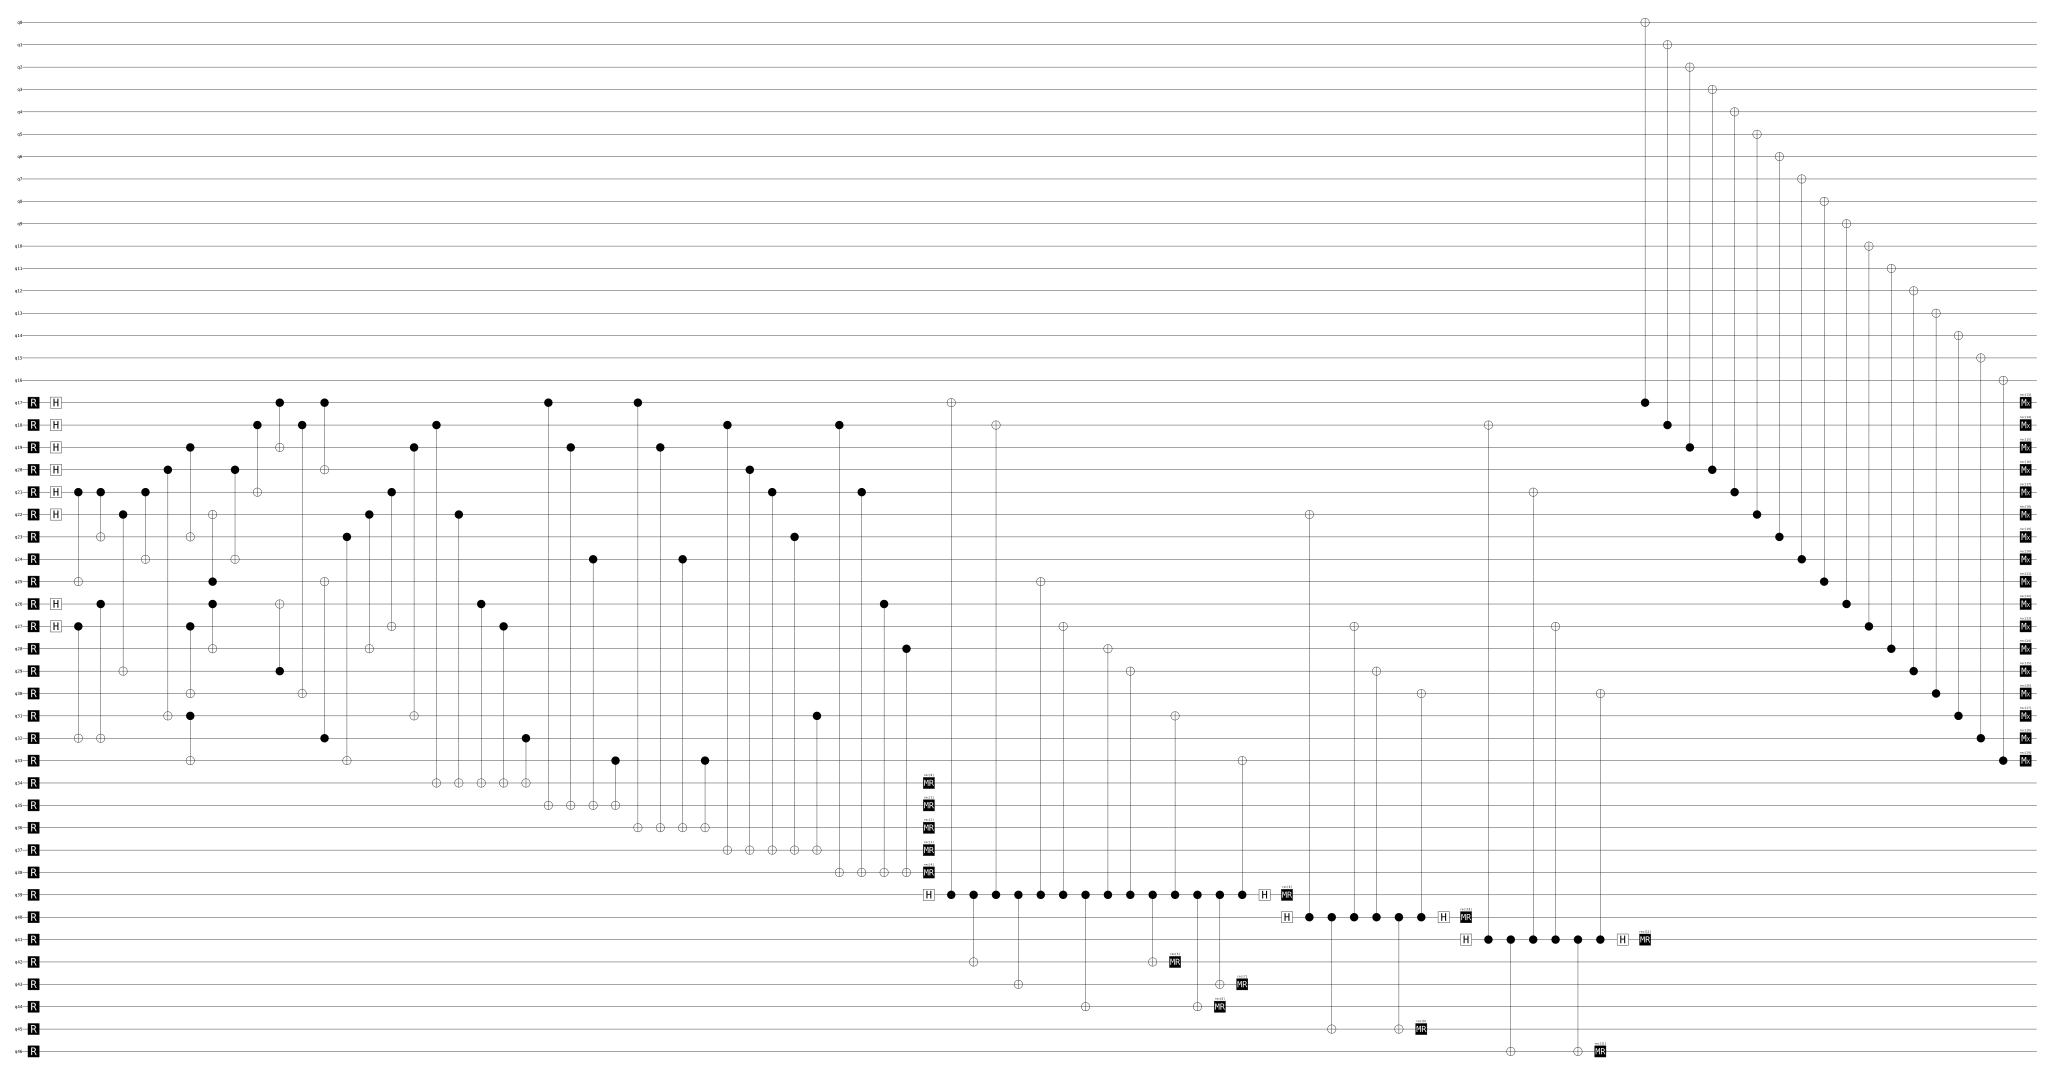

In [33]:
circuit = load_state_prep_circuit(circ_dir, circ_path)
se = steane_se_from_stim_state_prep(circuit, se_basis="Z", n=code.n)

print("Number of ancilla qubits necessary:", se.num_qubits - code.n)
se.diagram('timeline-svg')

In [34]:
samples = (perfect_state + se).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]
print(samples[:,:-code.n].astype(int))
print(samples[:,-code.n:] @ code.H_z.T % 2)

[[0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


Number of ancilla qubits necessary: 29
Mapping of new measurements to old measurements: {0: 16, 1: 1, 2: 15, 3: 2, 4: 20, 5: 13, 6: 0, 7: 28, 8: 3, 9: 19, 10: 4, 11: 22, 12: 14, 13: 17, 14: 21, 15: 11, 16: 23, 17: 24, 18: 5, 19: 9, 20: 10, 21: 25, 22: 6, 23: 12, 24: 27, 25: 7, 26: 8, 27: 26, 28: 29}


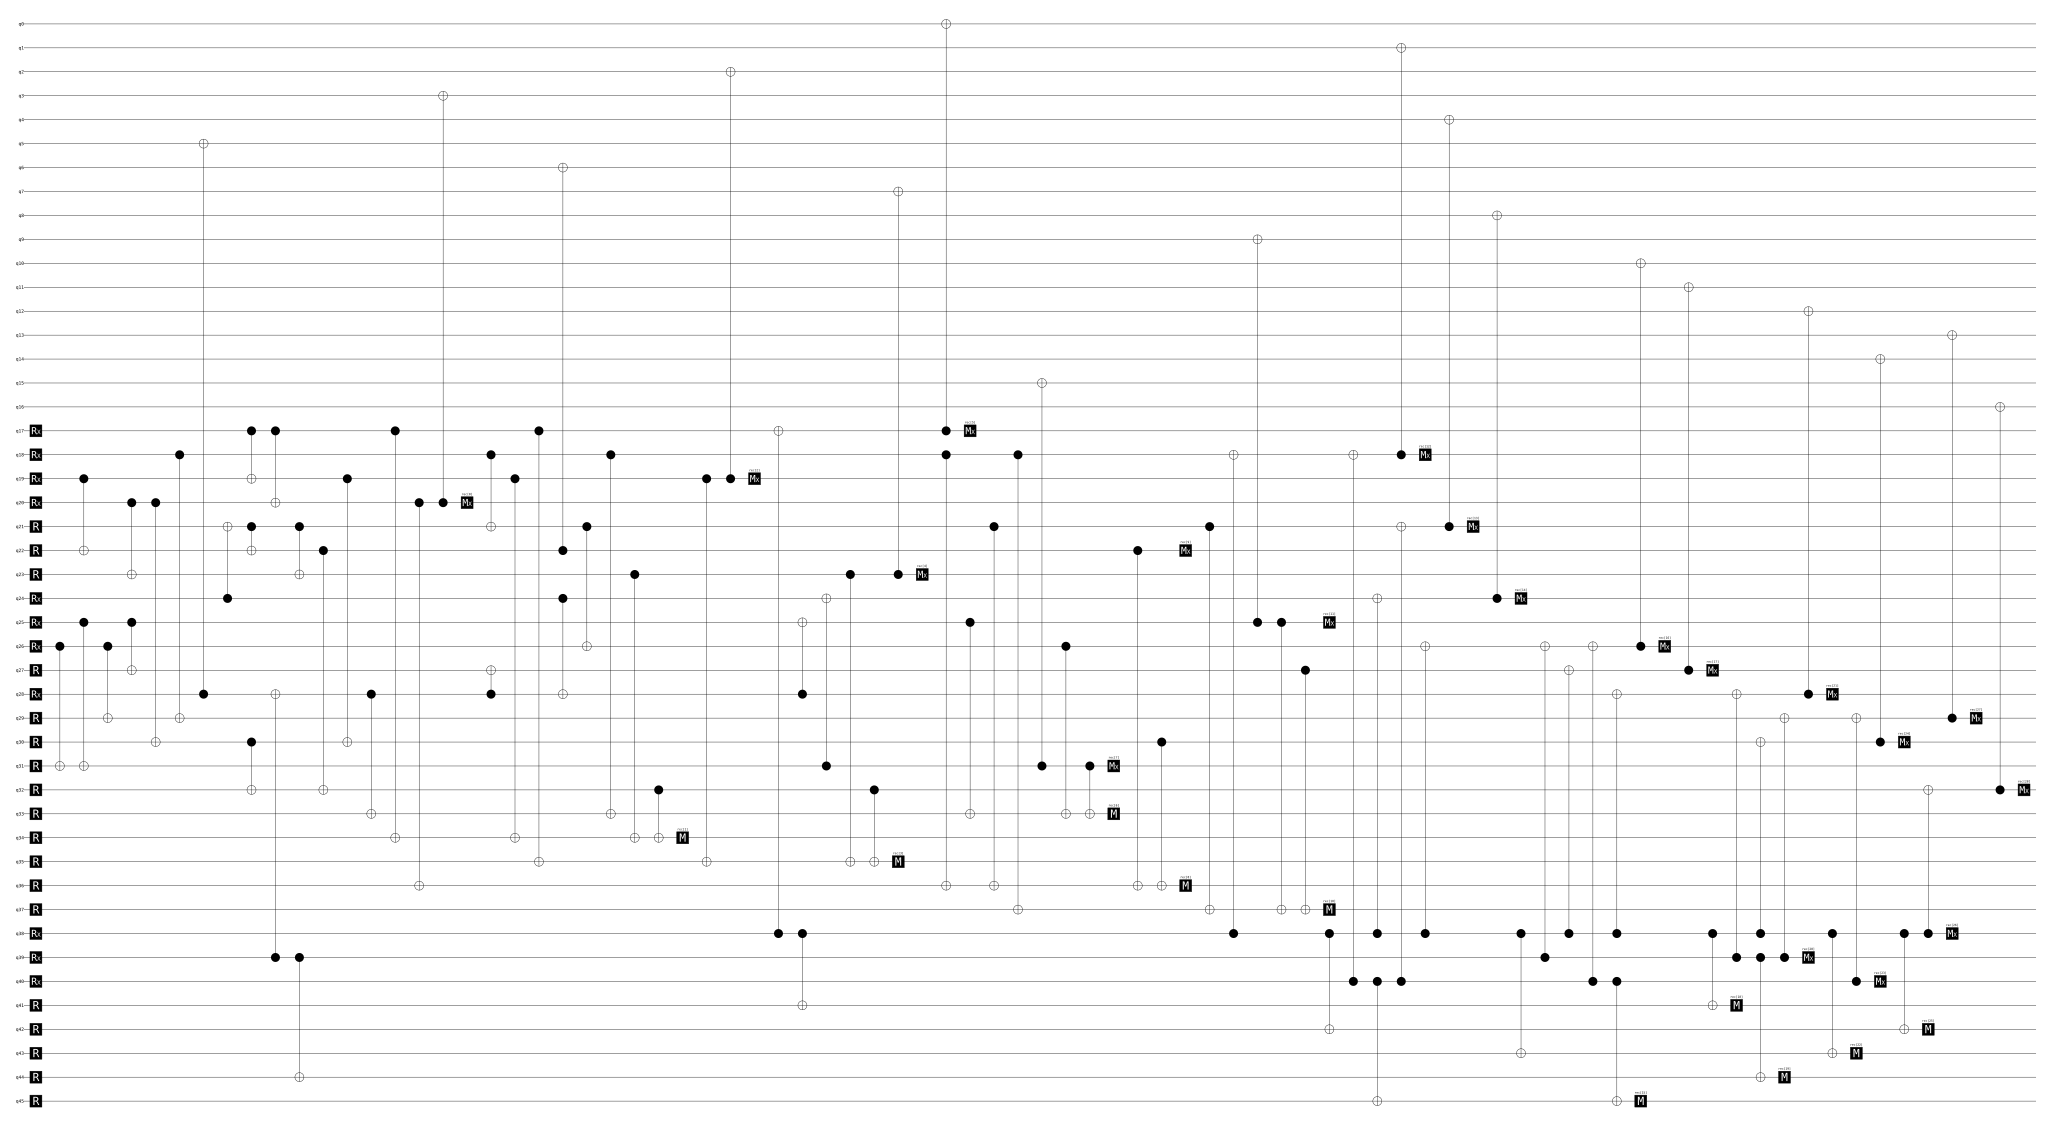

In [35]:
covered = CoveredZXGraph.from_stim(se)
covered.basic_FE_rewrites()


optimised = covered.greedy_best_first_boundary_bends(
    cost_func=LexicographicCost(metric_depth, metric_spacetime_volume_exact(VolumeOptimizingReuseStrategy)),
)
new_circuit, measurement_map = optimised.extract_circuit_with_measurement_map()

print("Number of ancilla qubits necessary:", new_circuit.num_qubits - code.n)
print("Mapping of new measurements to old measurements:", measurement_map)
new_circuit.diagram('timeline-svg')

In [36]:
samples = (perfect_state + new_circuit).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

num_measurements = get_num_measurements(se)
flag_indices = [k for k, v in measurement_map.items() if v < num_measurements - code.n]
flags = samples[:,flag_indices].astype(int)

print(samples.shape, num_measurements - len(flag_indices))

print("Flags:", flags, sep="\n", end="\n\n")

print("measurement_map:", measurement_map)
syndrome_indices = {k: v - (num_measurements - code.n) for k, v in measurement_map.items() if v >= num_measurements - code.n}
print("syndrome_indices:", syndrome_indices)
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2

print("Syndromes:", syndromes, sep="\n")

(10, 29) 17
Flags:
[[0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]]

measurement_map: {0: 16, 1: 1, 2: 15, 3: 2, 4: 20, 5: 13, 6: 0, 7: 28, 8: 3, 9: 19, 10: 4, 11: 22, 12: 14, 13: 17, 14: 21, 15: 11, 16: 23, 17: 24, 18: 5, 19: 9, 20: 10, 21: 25, 22: 6, 23: 12, 24: 27, 25: 7, 26: 8, 27: 26, 28: 29}
syndrome_indices: {0: 3, 2: 2, 4: 7, 5: 0, 7: 15, 9: 6, 11: 9, 12: 1, 13: 4, 14: 8, 16: 10, 17: 11, 21: 12, 24: 14, 27: 13, 28: 16}
Syndromes:
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


Number of ancilla qubits necessary: 24
Mapping of new measurements to old measurements: {0: 16, 1: 1, 2: 15, 3: 13, 4: 2, 5: 20, 6: 19, 7: 0, 8: 28, 9: 3, 10: 22, 11: 4, 12: 14, 13: 21, 14: 17, 15: 24, 16: 5, 17: 11, 18: 23, 19: 9, 20: 25, 21: 6, 22: 27, 23: 10, 24: 7, 25: 12, 26: 8, 27: 26, 28: 29}


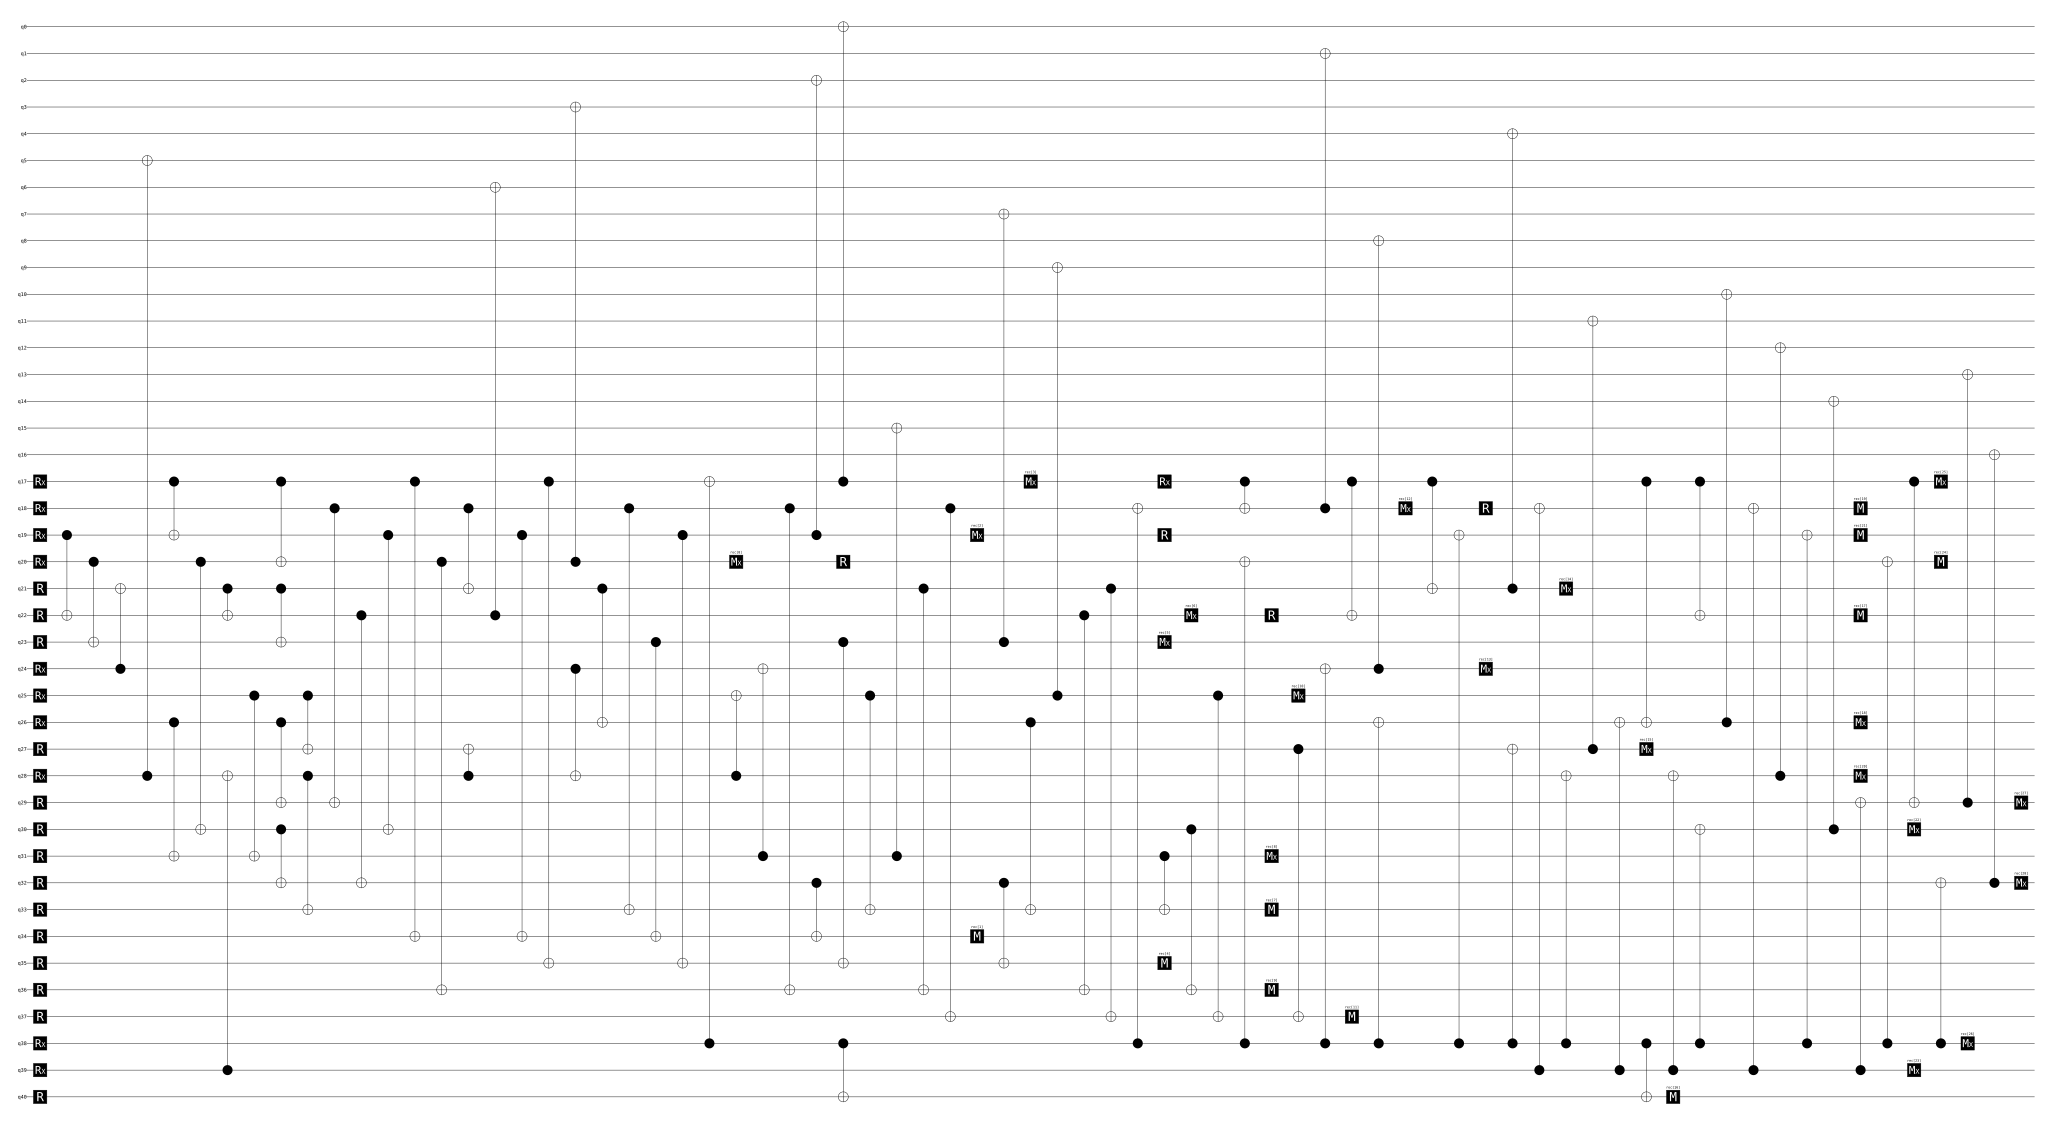

In [37]:
dag = build_circuit_dag(optimised)

mod_dag, logical_to_physical, total_hw = inject_qubit_reuse(dag, code.n, VolumeOptimizingReuseStrategy())
compressed_dag = apply_logical_qubit_merge_and_compress(mod_dag, code.n)
final_circ, final_meas_map = dag_to_circuit(compressed_dag)

print("Number of ancilla qubits necessary:", final_circ.num_qubits - code.n)
print("Mapping of new measurements to old measurements:", final_meas_map)
final_circ.diagram('timeline-svg')

In [21]:
samples = (perfect_state + final_circ).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

num_measurements = get_num_measurements(se)
flag_indices = [k for k, v in final_meas_map.items() if v < num_measurements - code.n]
flags = samples[:,flag_indices].astype(int)

print("Flags:", flags, sep="\n", end="\n\n")

syndrome_indices = {k: v - (num_measurements - code.n) for k, v in final_meas_map.items() if v >= num_measurements - code.n}
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2

print("Syndromes:", syndromes, sep="\n")

Flags:
[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]

Syndromes:
[[0 0 0 0 1]
 [0 1 1 0 0]
 [0 1 1 1 0]
 [0 0 0 1 1]
 [0 1 1 1 0]
 [0 0 0 0 1]
 [0 0 0 1 1]
 [0 1 1 1 0]
 [0 0 0 1 1]
 [0 0 0 0 1]]
